# StockLens RAG Pro — Developer Clean Colab

주식 초보자를 위한 **재무제표·차트지표 기반 RAG 학습 튜터**입니다.

이번 버전은 오류를 줄이기 위해 다음을 제거했습니다.

- `ragas` 직접 설치 없음
- `langchain` 없음
- `faiss` 없음
- `nest_asyncio` 없음

대신 다음 구조로 안정적으로 구현합니다.

- OpenAI API: 임베딩 + 답변 생성
- Numpy Vector Search: 벡터 검색
- BM25: 키워드 검색
- Hybrid Search: 벡터 + 키워드 결합
- Naive RAG: 원본 질문 + 벡터 검색 + 기본 답변
- Advanced RAG: 질문 유형 분류 + 규칙 기반 Multi-Query + Hybrid Search + 깊은 해석
- LLM-as-Judge: RAGAS 관점 4개 지표 평가
- 선택형 Gradio UI

> 이 노트북은 투자 학습용입니다. 매수·매도 추천을 제공하지 않습니다.

In [2]:
# ============================================================
# 1. 최소 패키지 설치
# ============================================================

!pip -q install -U openai rank-bm25 gradio pandas numpy tqdm matplotlib

print("설치 완료")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 109.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 36.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.6.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.
numba 0

In [3]:
# ============================================================
# 2. 기본 import + API 키 설정
# ============================================================

import os
import re
import json
import math
import time
import hashlib
import traceback
import subprocess
from pathlib import Path
from typing import List, Dict, Any

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from rank_bm25 import BM25Okapi
from openai import OpenAI

# ------------------------------------------------------------
# OpenAI API 키 로드
# Colab Secrets에 OPENAI_API_KEY로 저장하는 방식을 우선 사용합니다.
# ------------------------------------------------------------

def load_openai_key():
    key = None

    # 1) Colab Secrets
    try:
        from google.colab import userdata
        key = userdata.get("OPENAI_API_KEY")
    except Exception:
        key = None

    # 2) 환경변수
    if not key:
        key = os.environ.get("OPENAI_API_KEY")

    # 3) 직접 입력 fallback
    if not key:
        from getpass import getpass
        key = getpass("OpenAI API Key를 입력하세요: ")

    key = str(key).strip()

    # 실수 방지: Bearer, 따옴표, 공백, 줄바꿈 제거
    if key.lower().startswith("bearer "):
        key = key[7:].strip()
    key = key.replace('"', '').replace("'", '')
    key = re.sub(r"\s+", "", key)

    if not key.startswith("sk-"):
        raise ValueError("API 키 형식이 이상합니다. sk- 로 시작해야 합니다.")

    os.environ["OPENAI_API_KEY"] = key
    return key

OPENAI_API_KEY = load_openai_key()
client = OpenAI(api_key=OPENAI_API_KEY)

print("OpenAI API key loaded")
print("Key preview:", OPENAI_API_KEY[:7] + "..." + OPENAI_API_KEY[-4:])

OpenAI API key loaded
Key preview: sk-proj...N1IA


In [4]:
# ============================================================
# 3. 모델/경로 설정
# ============================================================

# 모델이 안 되면 이 셀에서 모델명만 바꾸면 됩니다.
CHAT_MODEL = "gpt-4o-mini"
EMBED_MODEL = "text-embedding-3-small"

WORK_DIR = Path("/content/stocklens_rag_pro")
DATA_DIR = WORK_DIR / "data"
CACHE_DIR = WORK_DIR / "cache"

DATA_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("CHAT_MODEL:", CHAT_MODEL)
print("EMBED_MODEL:", EMBED_MODEL)
print("WORK_DIR:", WORK_DIR)

CHAT_MODEL: gpt-4o-mini
EMBED_MODEL: text-embedding-3-small
WORK_DIR: /content/stocklens_rag_pro


In [5]:
# ============================================================
# 4. API 연결 테스트
# ============================================================

try:
    test_emb = client.embeddings.create(
        model=EMBED_MODEL,
        input="StockLens API test"
    )
    print("Embedding API OK")
    print("Embedding dim:", len(test_emb.data[0].embedding))

    test_chat = client.chat.completions.create(
        model=CHAT_MODEL,
        temperature=0,
        max_tokens=80,
        messages=[
            {"role": "system", "content": "짧게 답하세요."},
            {"role": "user", "content": "RAG를 한 문장으로 설명해줘."},
        ],
    )
    print("Chat API OK")
    print(test_chat.choices[0].message.content)

except Exception as e:
    print("API 테스트 실패")
    print(type(e).__name__, str(e))
    raise

Embedding API OK
Embedding dim: 1536
Chat API OK
RAG( Retrieval-Augmented Generation)는 외부 데이터베이스에서 정보를 검색하여 자연어 생성 모델의 응답을 보강하는 방법입니다.


In [6]:
# ============================================================
# 5. 주식 학습 문서 자동 생성
# ============================================================

DOCUMENTS = [
    {
        "source": "stock_terms.md",
        "title": "PER, PBR, ROE, EPS 기본 투자 지표",
        "category": "투자 용어",
        "text": """
PER은 주가수익비율이며 주가를 주당순이익 EPS로 나눈 값이다. PER이 낮으면 이익 대비 주가가 낮아 보일 수 있지만, 무조건 저평가라는 뜻은 아니다. 업종 평균, 이익 지속성, 성장률, 일회성 이익, 경기 사이클을 함께 봐야 한다. 경기민감주는 호황기에 이익이 커져 PER이 낮아 보이는 착시가 생길 수 있다.

PBR은 주가순자산비율이며 주가를 주당순자산으로 나눈 값이다. PBR 1배 이하는 자산가치 대비 주가가 낮다는 뜻이지만, ROE가 낮거나 성장성이 부족하면 계속 저평가 상태가 유지될 수 있다.

ROE는 자기자본이익률이다. 기업이 자기자본을 활용해 얼마나 이익을 냈는지 보여준다. ROE가 높으면 자본 효율성이 좋을 수 있지만, 부채 레버리지 때문에 ROE가 높아질 수도 있다.

EPS는 주당순이익이다. 순이익을 발행주식수로 나눈 값이다. EPS가 증가하면 같은 주가에서 PER은 낮아진다.
"""
    },
    {
        "source": "financial_statement_guide.md",
        "title": "재무제표 해석: 매출, 영업이익, 현금흐름, 재고",
        "category": "재무제표",
        "text": """
재무제표를 볼 때는 매출, 영업이익, 순이익, 영업현금흐름, 부채비율, 재고자산을 함께 봐야 한다. 매출이 증가했는데 영업이익이 감소했다면 원가율 상승, 판관비 증가, 가격 경쟁, 일회성 비용을 의심할 수 있다.

순이익이 증가했더라도 영업현금흐름이 나쁘면 실제 현금 창출력이 약할 수 있다. 재고자산이 빠르게 증가하면 판매 둔화, 수요 예측 실패, 가격 하락 가능성을 확인해야 한다.

부채비율이 높으면 이자비용과 재무 부담이 커질 수 있다. 다만 산업 특성에 따라 적정 부채비율은 다르므로 같은 업종 평균과 비교해야 한다.
"""
    },
    {
        "source": "sector_analysis.md",
        "title": "반도체, 전력기기, 바이오, ETF 섹터 분석",
        "category": "섹터 분석",
        "text": """
반도체 섹터는 메모리, 비메모리, 파운드리, 장비, 소재, 부품으로 나눌 수 있다. 반도체 기업을 볼 때는 업황 사이클, 재고, 고객사 CAPEX, AI 서버 수요, 영업이익률을 함께 봐야 한다.

전력기기 섹터는 AI 데이터센터, 전력망 투자, 변압기 교체 수요, 신재생에너지 확대와 연결된다. 전력기기 기업을 볼 때는 수주잔고, 해외 매출 비중, 영업이익률, 생산능력, 원자재 가격을 확인해야 한다.

바이오 섹터는 현재 실적보다 임상 단계, 기술이전, 파이프라인, 현금 보유액, 유상증자 가능성이 중요할 수 있다.

ETF를 볼 때는 구성 종목, 섹터 비중, 운용보수, 거래량, 추적오차, 상위 종목 집중도를 함께 봐야 한다.
"""
    },
    {
        "source": "chart_upper_indicators.md",
        "title": "이동평균선 Moving Average",
        "category": "상단 지표",
        "text": """
이동평균선은 일정 기간 동안의 평균 가격을 선으로 연결한 지표다. 주가의 단기 변동을 완화하고 추세 방향을 확인하는 데 사용한다. 5일선은 단기 매매 심리, 20일선은 단기 추세, 60일선은 중기 추세, 120일선은 장기 추세를 보는 데 자주 사용된다.

주가가 이동평균선 위에 있으면 해당 기간 평균 매수자보다 현재 가격이 높다는 뜻이다. 단기선이 장기선을 위로 돌파하면 골든크로스, 아래로 이탈하면 데드크로스라고 부른다.

하지만 골든크로스가 항상 상승을 보장하지 않는다. 횡보장에서는 골든크로스와 데드크로스가 반복되는 속임수 신호가 많다. 이동평균선 돌파를 볼 때는 거래량, MACD, RSI, 지지선과 저항선을 함께 확인해야 한다.
"""
    },
    {
        "source": "chart_upper_indicators.md",
        "title": "일목균형표 Ichimoku Cloud",
        "category": "상단 지표",
        "text": """
일목균형표는 추세, 지지와 저항, 매수와 매도 균형을 한 번에 보기 위한 지표다. 주요 구성 요소는 전환선, 기준선, 선행스팬1, 선행스팬2, 후행스팬, 구름대다.

주가가 구름대 위에 있으면 상승 추세가 우세하다고 볼 수 있고, 구름대 아래에 있으면 하락 추세가 우세하다고 볼 수 있다. 구름대가 두꺼우면 지지와 저항이 강하다고 해석할 수 있다.

주의할 점은 구름대 돌파가 항상 추세 전환을 의미하지는 않는다는 것이다. 거래량이 부족하거나 돌파 후 다시 구름 안으로 들어오면 속임수 돌파일 수 있다. 일목균형표는 이동평균선, 거래량, MACD와 함께 보는 것이 좋다.
"""
    },
    {
        "source": "chart_upper_indicators.md",
        "title": "볼린저밴드 Bollinger Bands",
        "category": "상단 지표",
        "text": """
볼린저밴드는 이동평균선과 표준편차를 이용해 가격의 변동 범위를 보여주는 지표다. 중심선은 보통 20일 이동평균선이며, 상단 밴드는 중심선에 2표준편차를 더하고, 하단 밴드는 중심선에서 2표준편차를 뺀 값이다.

밴드 폭이 좁아지면 변동성이 줄어든 상태이고, 밴드 폭이 넓어지면 변동성이 커진 상태다. 주가가 상단 밴드에 닿으면 강한 상승 흐름 또는 단기 과열 가능성이 있다. 주가가 하단 밴드에 닿으면 약세 흐름 또는 과매도 가능성이 있다.

상단 밴드 돌파가 무조건 매도 신호는 아니다. 강한 상승장에서는 주가가 상단 밴드를 타고 계속 오르는 밴드 워크가 나올 수 있다. 하단 밴드 터치도 무조건 매수 신호가 아니다. 하락 추세에서는 하단 밴드를 타고 더 내려갈 수 있다.
"""
    },
    {
        "source": "chart_upper_indicators.md",
        "title": "VWAP, 지지선, 저항선, 추세선",
        "category": "상단 지표",
        "text": """
VWAP은 거래량가중평균가격이다. 가격과 거래량을 함께 반영하여 당일 평균 매매 가격을 보여준다. 주가가 VWAP 위에 있으면 당일 평균 매수자보다 유리한 가격에 거래되고 있다고 볼 수 있고, VWAP 아래에 있으면 약세로 볼 수 있다.

지지선은 가격이 하락할 때 매수세가 유입되어 반등하기 쉬운 가격대이고, 저항선은 가격이 상승할 때 매도세가 나와 막히기 쉬운 가격대다. 추세선은 고점과 고점 또는 저점과 저점을 연결해 방향성을 보는 도구다.

지지선과 저항선은 절대적인 선이 아니라 가격대 영역으로 봐야 한다. 돌파와 이탈은 거래량이 함께 증가할 때 신뢰도가 높아진다.
"""
    },
    {
        "source": "chart_lower_indicators.md",
        "title": "RSI Relative Strength Index",
        "category": "하단 지표",
        "text": """
RSI는 일정 기간 동안 상승폭과 하락폭을 비교해 과매수와 과매도 상태를 판단하는 모멘텀 지표다. 보통 RSI 70 이상은 과매수권, RSI 30 이하는 과매도권으로 본다.

RSI가 높다는 것은 최근 상승 압력이 강했다는 뜻이고, RSI가 낮다는 것은 최근 하락 압력이 강했다는 뜻이다. 그러나 RSI 70 이상이라고 무조건 매도 신호는 아니다. 강한 상승 추세에서는 RSI가 70 이상에서 오래 머물 수 있다.

RSI 30 이하라고 무조건 매수 신호도 아니다. 강한 하락 추세에서는 RSI가 낮은 상태로 오래 유지될 수 있다. RSI는 이동평균선, 볼린저밴드, 거래량, MACD와 함께 봐야 한다.
"""
    },
    {
        "source": "chart_lower_indicators.md",
        "title": "MACD Moving Average Convergence Divergence",
        "category": "하단 지표",
        "text": """
MACD는 단기 이동평균과 장기 이동평균의 차이를 이용해 추세 전환과 모멘텀을 보는 지표다. 구성 요소는 MACD선, Signal선, Histogram이다.

MACD선이 Signal선을 위로 돌파하면 골든크로스이고, 아래로 이탈하면 데드크로스다. Histogram이 커지면 모멘텀이 강해지고 있다고 볼 수 있다.

MACD는 이동평균 기반 지표라 신호가 늦게 나올 수 있다. 횡보장에서는 골든크로스와 데드크로스가 자주 발생해 속임수 신호가 많다. MACD는 이동평균선, 거래량, RSI, ADX와 함께 보는 것이 좋다.
"""
    },
    {
        "source": "chart_lower_indicators.md",
        "title": "거래량 Volume, OBV, MFI",
        "category": "하단 지표",
        "text": """
거래량은 일정 기간 동안 거래된 주식 수량이다. 가격 움직임의 신뢰도를 판단하는 핵심 지표다. 상승하면서 거래량이 증가하면 매수세가 강하다고 볼 수 있고, 하락하면서 거래량이 증가하면 매도세가 강하다고 볼 수 있다.

가격은 상승하지만 거래량이 줄면 상승 힘이 약할 수 있다. 고점에서 거래량이 급증하면 매집이 아니라 차익실현이나 분산일 수 있다. 저점에서 거래량이 급증하면 투매 후 반등 또는 매집 가능성을 검토할 수 있다.

OBV는 거래량을 이용해 매집과 분산 흐름을 보는 지표다. MFI는 가격과 거래량을 함께 이용하는 자금흐름 지표다.
"""
    },
    {
        "source": "chart_lower_indicators.md",
        "title": "ADX, DMI, 스토캐스틱, ATR",
        "category": "하단 지표",
        "text": """
ADX는 추세의 강도를 보여주는 지표다. ADX는 방향이 아니라 추세 강도만 보여준다. ADX가 높다고 무조건 상승이 아니다. 강한 하락 추세에서도 ADX는 높게 나올 수 있다.

DMI는 +DI와 -DI로 상승 방향성과 하락 방향성을 비교한다. +DI가 -DI보다 높으면 상승 방향성이 우세하고, -DI가 +DI보다 높으면 하락 방향성이 우세하다.

스토캐스틱은 현재 가격이 일정 기간 고가와 저가 범위 안에서 어디에 위치하는지 보는 모멘텀 지표다. ATR은 평균 진폭을 보여주는 변동성 지표다. ATR이 크면 변동성이 커졌다는 뜻이다.
"""
    },
    {
        "source": "indicator_combinations.md",
        "title": "지표 조합 해석: 이동평균선, 거래량, RSI, MACD, 볼린저밴드",
        "category": "지표 조합",
        "text": """
이동평균선 돌파와 거래량을 함께 봐야 한다. 주가가 주요 이동평균선을 돌파할 때 거래량이 함께 증가하면 돌파 신뢰도가 높아질 수 있다. 반대로 거래량 없이 이동평균선을 돌파하면 속임수 돌파일 가능성이 있다.

볼린저밴드와 RSI를 함께 볼 수 있다. 주가가 볼린저밴드 상단에 닿고 RSI가 70 이상이면 단기 과열 가능성이 있다. 그러나 강한 상승장에서는 상단 밴드를 타고 상승하는 밴드 워크가 나올 수 있으므로 단독 매도 신호로 보면 안 된다.

MACD 골든크로스가 나오고 주가가 20일선 위에 있으면 단기 상승 모멘텀이 개선되는 구간으로 해석할 수 있다. 하지만 주가가 60일선이나 120일선 아래에 있으면 중장기 추세는 아직 약할 수 있다.

일목균형표 구름대 돌파와 거래량을 함께 봐야 한다. 주가가 구름대를 상향 돌파할 때 거래량이 증가하면 추세 전환 신뢰도가 높아질 수 있다.
"""
    },
    {
        "source": "chart_misconceptions.md",
        "title": "차트 지표 관련 투자 오해",
        "category": "투자 오해",
        "text": """
골든크로스가 나오면 무조건 오른다는 생각은 위험하다. 골든크로스는 단기 평균 가격이 장기 평균 가격을 위로 돌파했다는 뜻이지만, 횡보장에서는 속임수 신호가 자주 발생한다.

RSI 70 이상이면 무조건 팔아야 한다는 생각도 위험하다. RSI 70 이상은 과열 가능성을 의미하지만 강한 상승 추세에서는 RSI가 높은 상태로 오래 유지될 수 있다.

볼린저밴드 하단에 닿으면 무조건 사야 한다는 생각도 위험하다. 하락 추세에서는 주가가 하단 밴드를 타고 계속 내려갈 수 있다.

거래량이 터지면 무조건 좋은 신호라는 생각도 위험하다. 고점에서 거래량이 터지면 세력의 분산이나 차익실현일 수 있다.
"""
    },
    {
        "source": "investment_misconceptions.md",
        "title": "재무지표와 투자 판단 오해",
        "category": "투자 오해",
        "text": """
PER이 낮으면 무조건 저평가라는 생각은 위험하다. PER은 업종 평균, 성장률, 이익 지속성, 일회성 이익 여부와 함께 봐야 한다.

PBR 1배 이하면 무조건 싸다는 생각도 위험하다. PBR이 낮아도 ROE가 낮거나 성장성이 부족하면 저평가 상태가 오래 지속될 수 있다.

고배당주는 무조건 안전하다는 생각도 위험하다. 배당성향이 지나치게 높거나 이익이 줄면 배당이 감소할 수 있다.

매출이 늘면 무조건 좋은 기업이라는 생각도 위험하다. 매출 증가와 함께 영업이익률, 현금흐름, 재고자산을 확인해야 한다.
"""
    },
]

# 파일로도 저장
for doc in DOCUMENTS:
    path = DATA_DIR / doc["source"]
    with open(path, "a", encoding="utf-8") as f:
        f.write(f"\n\n# {doc['title']}\n\n{doc['text'].strip()}\n")

print("문서 개수:", len(DOCUMENTS))
pd.DataFrame([{k: v for k, v in d.items() if k != "text"} for d in DOCUMENTS])

문서 개수: 14


,source,title,category
0,stock_terms.md,"PER, PBR, ROE, EPS 기본 투자 지표",투자 용어
1,financial_statement_guide.md,"재무제표 해석: 매출, 영업이익, 현금흐름, 재고",재무제표
2,sector_analysis.md,"반도체, 전력기기, 바이오, ETF 섹터 분석",섹터 분석
3,chart_upper_indicators.md,이동평균선 Moving Average,상단 지표
4,chart_upper_indicators.md,일목균형표 Ichimoku Cloud,상단 지표
5,chart_upper_indicators.md,볼린저밴드 Bollinger Bands,상단 지표
6,chart_upper_indicators.md,"VWAP, 지지선, 저항선, 추세선",상단 지표
7,chart_lower_indicators.md,RSI Relative Strength Index,하단 지표
8,chart_lower_indicators.md,MACD Moving Average Convergence Divergence,하단 지표
9,chart_lower_indicators.md,"거래량 Volume, OBV, MFI",하단 지표


In [7]:
# ============================================================
# 6. 문서 청킹
# ============================================================

# 문서가 짧기 때문에 단락 기준으로 자르고, 너무 길면 sliding window로 자릅니다.

def split_text(text: str, max_chars: int = 900, overlap: int = 120) -> List[str]:
    text = re.sub(r"\n{3,}", "\n\n", text.strip())
    paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]

    chunks = []
    buf = ""

    for p in paragraphs:
        if len(buf) + len(p) + 2 <= max_chars:
            buf = (buf + "\n\n" + p).strip()
        else:
            if buf:
                chunks.append(buf)
            buf = p

    if buf:
        chunks.append(buf)

    final_chunks = []
    for ch in chunks:
        if len(ch) <= max_chars:
            final_chunks.append(ch)
        else:
            start = 0
            while start < len(ch):
                final_chunks.append(ch[start:start + max_chars])
                start += max_chars - overlap

    return final_chunks

all_docs = []

for doc_idx, doc in enumerate(DOCUMENTS):
    chunks = split_text(doc["text"], max_chars=900, overlap=120)
    for chunk_idx, chunk in enumerate(chunks):
        all_docs.append({
            "id": f"doc{doc_idx:02d}_chunk{chunk_idx:02d}",
            "source": doc["source"],
            "title": doc["title"],
            "category": doc["category"],
            "text": chunk,
        })

print("chunk 개수:", len(all_docs))
pd.DataFrame([{k: v for k, v in d.items() if k != "text"} for d in all_docs]).head(10)

chunk 개수: 14


,id,source,title,category
0,doc00_chunk00,stock_terms.md,"PER, PBR, ROE, EPS 기본 투자 지표",투자 용어
1,doc01_chunk00,financial_statement_guide.md,"재무제표 해석: 매출, 영업이익, 현금흐름, 재고",재무제표
2,doc02_chunk00,sector_analysis.md,"반도체, 전력기기, 바이오, ETF 섹터 분석",섹터 분석
3,doc03_chunk00,chart_upper_indicators.md,이동평균선 Moving Average,상단 지표
4,doc04_chunk00,chart_upper_indicators.md,일목균형표 Ichimoku Cloud,상단 지표
5,doc05_chunk00,chart_upper_indicators.md,볼린저밴드 Bollinger Bands,상단 지표
6,doc06_chunk00,chart_upper_indicators.md,"VWAP, 지지선, 저항선, 추세선",상단 지표
7,doc07_chunk00,chart_lower_indicators.md,RSI Relative Strength Index,하단 지표
8,doc08_chunk00,chart_lower_indicators.md,MACD Moving Average Convergence Divergence,하단 지표
9,doc09_chunk00,chart_lower_indicators.md,"거래량 Volume, OBV, MFI",하단 지표


In [8]:
# ============================================================
# 7. Embedding 생성 + 캐시
# ============================================================

texts_for_embedding = [
    f"[카테고리] {d['category']}\n[제목] {d['title']}\n[본문]\n{d['text']}"
    for d in all_docs
]

corpus_hash = hashlib.md5("\n".join(texts_for_embedding).encode("utf-8")).hexdigest()[:12]
emb_path = CACHE_DIR / f"embeddings_{corpus_hash}.npy"
meta_path = CACHE_DIR / f"metadata_{corpus_hash}.json"


def embed_texts(texts: List[str], batch_size: int = 32) -> np.ndarray:
    clean_texts = [str(t).strip() if str(t).strip() else "empty" for t in texts]
    vectors = []

    for i in tqdm(range(0, len(clean_texts), batch_size), desc="Embedding"):
        batch = clean_texts[i:i + batch_size]
        resp = client.embeddings.create(
            model=EMBED_MODEL,
            input=batch,
        )
        vectors.extend([item.embedding for item in resp.data])

    return np.array(vectors, dtype=np.float32)

if emb_path.exists() and meta_path.exists():
    embedding_matrix = np.load(emb_path)
    print("캐시된 embedding 사용:", emb_path)
else:
    embedding_matrix = embed_texts(texts_for_embedding)
    np.save(emb_path, embedding_matrix)
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump({"corpus_hash": corpus_hash, "count": len(all_docs)}, f, ensure_ascii=False, indent=2)
    print("embedding 생성 및 저장 완료:", emb_path)

# cosine 검색을 위해 정규화
norms = np.linalg.norm(embedding_matrix, axis=1, keepdims=True)
norms[norms == 0] = 1.0
embedding_matrix_norm = embedding_matrix / norms

print("embedding shape:", embedding_matrix_norm.shape)

Embedding:   0%|          | 0/1 [00:00<?, ?it/s]

embedding 생성 및 저장 완료: /content/stocklens_rag_pro/cache/embeddings_c3d25f73f8f4.npy
embedding shape: (14, 1536)


In [9]:
# ============================================================
# 8. BM25 인덱스 생성
# ============================================================


def tokenize(text: str) -> List[str]:
    # 한글/영문/숫자/기호 일부 보존
    return re.findall(r"[가-힣A-Za-z0-9%+\-_.]+", str(text).lower())

bm25_corpus = [tokenize(t) for t in texts_for_embedding]
bm25 = BM25Okapi(bm25_corpus)

print("BM25 문서 수:", len(bm25_corpus))

BM25 문서 수: 14


In [10]:
# ============================================================
# 9. 검색 함수: Vector / BM25 / Hybrid
# ============================================================

query_embedding_cache = {}


def embed_query(query: str) -> np.ndarray:
    query = str(query).strip()
    if query in query_embedding_cache:
        return query_embedding_cache[query]

    vec = embed_texts([query], batch_size=1)[0]
    norm = np.linalg.norm(vec)
    if norm == 0:
        norm = 1.0
    vec = vec / norm
    query_embedding_cache[query] = vec.astype(np.float32)
    return query_embedding_cache[query]


def vector_search(query: str, top_k: int = 5) -> List[Dict[str, Any]]:
    q_vec = embed_query(query)
    scores = embedding_matrix_norm @ q_vec
    top_idx = np.argsort(scores)[::-1][:top_k]

    results = []
    for rank, idx in enumerate(top_idx, start=1):
        d = dict(all_docs[int(idx)])
        d["score"] = float(scores[int(idx)])
        d["rank"] = rank
        d["search_type"] = "vector"
        results.append(d)
    return results


def bm25_search(query: str, top_k: int = 5) -> List[Dict[str, Any]]:
    tokens = tokenize(query)
    scores = bm25.get_scores(tokens)
    top_idx = np.argsort(scores)[::-1][:top_k]

    results = []
    for rank, idx in enumerate(top_idx, start=1):
        d = dict(all_docs[int(idx)])
        d["score"] = float(scores[int(idx)])
        d["rank"] = rank
        d["search_type"] = "bm25"
        results.append(d)
    return results


def hybrid_search(query: str, top_k: int = 6, vector_k: int = 8, bm25_k: int = 8) -> List[Dict[str, Any]]:
    candidates = {}

    for rank, d in enumerate(vector_search(query, top_k=vector_k), start=1):
        doc_id = d["id"]
        candidates.setdefault(doc_id, dict(d))
        candidates[doc_id]["rrf_score"] = candidates[doc_id].get("rrf_score", 0.0) + 1 / (60 + rank)
        candidates[doc_id].setdefault("matched_by", []).append("vector")

    for rank, d in enumerate(bm25_search(query, top_k=bm25_k), start=1):
        doc_id = d["id"]
        candidates.setdefault(doc_id, dict(d))
        candidates[doc_id]["rrf_score"] = candidates[doc_id].get("rrf_score", 0.0) + 1 / (60 + rank)
        candidates[doc_id].setdefault("matched_by", []).append("bm25")

    results = sorted(candidates.values(), key=lambda x: x.get("rrf_score", 0.0), reverse=True)[:top_k]
    for rank, d in enumerate(results, start=1):
        d["rank"] = rank
        d["score"] = float(d.get("rrf_score", d.get("score", 0.0)))
        d["search_type"] = "hybrid"
    return results

# 검색 테스트
test_query = "RSI 70 이상이고 볼린저밴드 상단에 닿으면 팔아야 하나요?"
for r in hybrid_search(test_query, top_k=5):
    print(r["rank"], r["source"], "/", r["title"], "/", r["category"], "/", round(r["score"], 4))

Embedding:   0%|          | 0/1 [00:00<?, ?it/s]

1 chart_misconceptions.md / 차트 지표 관련 투자 오해 / 투자 오해 / 0.0328
2 chart_upper_indicators.md / 볼린저밴드 Bollinger Bands / 상단 지표 / 0.0318
3 indicator_combinations.md / 지표 조합 해석: 이동평균선, 거래량, RSI, MACD, 볼린저밴드 / 지표 조합 / 0.0318
4 chart_lower_indicators.md / RSI Relative Strength Index / 하단 지표 / 0.0317
5 chart_lower_indicators.md / MACD Moving Average Convergence Divergence / 하단 지표 / 0.0305


In [11]:
# ============================================================
# 10. RAG 공통 유틸
# ============================================================


def call_llm(system_prompt: str, user_prompt: str, temperature: float = 0.2, max_tokens: int = 1400) -> str:
    resp = client.chat.completions.create(
        model=CHAT_MODEL,
        temperature=temperature,
        max_tokens=max_tokens,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
    )
    return resp.choices[0].message.content.strip()


def build_context(docs: List[Dict[str, Any]], max_chars_per_doc: int = 900) -> str:
    blocks = []
    for i, d in enumerate(docs, start=1):
        text = d.get("text", "")[:max_chars_per_doc]
        blocks.append(
            f"[문서 {i}]\n"
            f"출처: {d.get('source', 'unknown')}\n"
            f"제목: {d.get('title', 'unknown')}\n"
            f"카테고리: {d.get('category', 'unknown')}\n"
            f"내용:\n{text}"
        )
    return "\n\n".join(blocks)


def format_docs(docs: List[Dict[str, Any]]) -> str:
    if not docs:
        return "검색된 문서 없음"
    lines = []
    for d in docs:
        lines.append(
            f"- {d.get('source')} / {d.get('title')} / {d.get('category')} / score={d.get('score', 0):.4f}"
        )
    return "\n".join(lines)

In [12]:
# ============================================================
# 11. 질문 분류 + Multi-Query 확장
# ============================================================


def classify_question(question: str) -> str:
    q = question.lower()

    upper = ["이동평균", "이평", "일목", "구름대", "볼린저", "vwap", "지지선", "저항선", "추세선"]
    lower = ["rsi", "macd", "거래량", "스토캐스틱", "adx", "dmi", "obv", "mfi", "atr", "cci"]
    finance = ["per", "pbr", "roe", "eps", "부채", "영업이익", "순이익", "매출", "현금흐름", "재고", "배당"]
    sector = ["반도체", "전력", "전력기기", "바이오", "etf", "데이터센터", "ai"]
    misconception = ["무조건", "사야", "팔아", "매수", "매도", "좋은", "안전", "저평가", "위험"]

    if any(k in q for k in upper):
        return "상단 차트 지표"
    if any(k in q for k in lower):
        return "하단 차트 지표"
    if any(k in q for k in finance):
        return "재무/투자 지표"
    if any(k in q for k in sector):
        return "섹터 분석"
    if any(k in q for k in misconception):
        return "투자 오해 교정"
    return "일반 주식 학습"


def expand_queries(question: str) -> List[str]:
    label = classify_question(question)
    q = question.strip()
    queries = [q]

    common = [
        f"{q} 의미와 해석 기준",
        f"{q} 초보자가 자주 하는 오해와 주의점",
        f"{q} 함께 볼 지표와 체크리스트",
    ]
    queries.extend(common)

    if label == "상단 차트 지표":
        queries.extend([
            "이동평균선 볼린저밴드 일목균형표 지지 저항 거래량 돌파 신뢰도",
            "상단 지표 추세 판단 상승장 하락장 횡보장 속임수 돌파",
        ])
    elif label == "하단 차트 지표":
        queries.extend([
            "RSI MACD 거래량 ADX OBV 과매수 과매도 모멘텀 속임수 신호",
            "하단 지표 추세장 횡보장 해석과 함께 볼 지표",
        ])
    elif label == "재무/투자 지표":
        queries.extend([
            "PER PBR ROE EPS 영업이익 현금흐름 부채비율 해석 주의점",
            "재무제표 투자 지표 저평가 오해 성장성 이익 지속성",
        ])
    elif label == "섹터 분석":
        queries.extend([
            "반도체 전력기기 바이오 ETF 섹터 분석 핵심 지표",
            "AI 데이터센터 전력기기 수주잔고 해외매출 영업이익률",
        ])
    else:
        queries.extend([
            "투자 오해 교정 무조건 매수 매도 위험 체크리스트",
            "주식 초보자 학습용 설명 근거 기반 해석",
        ])

    deduped = []
    for item in queries:
        if item not in deduped:
            deduped.append(item)
    return deduped[:6]

q = "이동평균선 20일선을 돌파했는데 거래량이 별로 없으면 어떻게 봐야 하나요?"
print("label:", classify_question(q))
print("queries:")
for x in expand_queries(q):
    print("-", x)

label: 상단 차트 지표
queries:
- 이동평균선 20일선을 돌파했는데 거래량이 별로 없으면 어떻게 봐야 하나요?
- 이동평균선 20일선을 돌파했는데 거래량이 별로 없으면 어떻게 봐야 하나요? 의미와 해석 기준
- 이동평균선 20일선을 돌파했는데 거래량이 별로 없으면 어떻게 봐야 하나요? 초보자가 자주 하는 오해와 주의점
- 이동평균선 20일선을 돌파했는데 거래량이 별로 없으면 어떻게 봐야 하나요? 함께 볼 지표와 체크리스트
- 이동평균선 볼린저밴드 일목균형표 지지 저항 거래량 돌파 신뢰도
- 상단 지표 추세 판단 상승장 하락장 횡보장 속임수 돌파


In [13]:
# ============================================================
# 12. Naive RAG / Advanced RAG 구현
# ============================================================


def naive_rag(question: str, top_k: int = 3) -> Dict[str, Any]:
    """
    Naive RAG:
    - 질문 그대로 사용
    - Vector Search만 사용
    - 기본 개념 중심의 짧은 답변
    """
    docs = vector_search(question, top_k=top_k)
    context = build_context(docs, max_chars_per_doc=700)

    system_prompt = """
너는 주식 초보자를 위한 기본 RAG 학습 튜터다.
반드시 제공된 근거 문서만 사용한다.

Naive RAG 규칙:
- 질문을 재작성하지 않는다.
- 검색된 문서의 핵심만 간단히 설명한다.
- 조건별 해석, 복합 지표 분석, 긴 체크리스트는 하지 않는다.
- 매수·매도 추천은 하지 않는다.
"""

    user_prompt = f"""
[질문]
{question}

[검색된 근거 문서]
{context}

아래 형식으로 짧게 답변해라.

1. 핵심 결론:
2. 기본 설명:
3. 주의할 점:
4. 학습용 안내:
"""

    answer = call_llm(system_prompt, user_prompt, temperature=0.1, max_tokens=1000)
    return {
        "mode": "Naive RAG",
        "answer": answer,
        "docs": docs,
        "queries": [question],
        "label": "원본 질문 기반 벡터 검색",
    }


def advanced_retrieve(question: str, top_k: int = 6) -> Dict[str, Any]:
    label = classify_question(question)
    queries = expand_queries(question)

    candidates = {}
    for query in queries:
        docs = hybrid_search(query, top_k=top_k, vector_k=8, bm25_k=8)
        for rank, d in enumerate(docs, start=1):
            doc_id = d["id"]
            if doc_id not in candidates:
                candidates[doc_id] = dict(d)
                candidates[doc_id]["advanced_score"] = 0.0
                candidates[doc_id]["matched_queries"] = []
            candidates[doc_id]["advanced_score"] += 1 / (60 + rank)
            candidates[doc_id]["matched_queries"].append(query)

    docs = sorted(candidates.values(), key=lambda x: x.get("advanced_score", 0), reverse=True)

    selected = []
    seen_titles = set()
    for d in docs:
        title = d.get("title", "")
        if title not in seen_titles:
            selected.append(d)
            seen_titles.add(title)
        if len(selected) >= top_k:
            break

    if len(selected) < top_k:
        for d in docs:
            if d not in selected:
                selected.append(d)
            if len(selected) >= top_k:
                break

    return {
        "label": label,
        "queries": queries,
        "docs": selected[:top_k],
    }


def advanced_rag(question: str, top_k: int = 6) -> Dict[str, Any]:
    """
    Advanced RAG:
    - 질문 유형 분류
    - 규칙 기반 Multi-Query 확장
    - Hybrid Search
    - 다양한 문서 통합
    - 조건별 해석 + 오해 교정 + 체크리스트
    """
    retrieved = advanced_retrieve(question, top_k=top_k)
    docs = retrieved["docs"]
    queries = retrieved["queries"]
    label = retrieved["label"]
    context = build_context(docs, max_chars_per_doc=1000)

    system_prompt = """
너는 주식 초보자를 위한 Advanced RAG 투자 학습 튜터다.
반드시 제공된 근거 문서에 기반해 답한다.

Advanced RAG 규칙:
- 단순 정의에서 끝내지 말고 해석 기준까지 설명한다.
- 초보자가 자주 하는 오해를 반드시 교정한다.
- 상승장, 하락장, 횡보장처럼 조건별 해석을 구분한다.
- 단일 지표가 아니라 함께 볼 지표까지 연결한다.
- 질문이 매수·매도 판단처럼 보여도 직접 추천하지 말고 학습용 판단 기준으로 바꿔 설명한다.
- 마지막에 체크리스트를 포함한다.
"""

    user_prompt = f"""
[질문 유형]
{label}

[원본 질문]
{question}

[확장 검색 질문]
{chr(10).join('- ' + q for q in queries)}

[검색된 근거 문서]
{context}

아래 형식으로 답변해라.

1. 핵심 결론:
2. 쉬운 설명:
3. 조건별 해석:
   - 상승 추세:
   - 하락 추세:
   - 횡보장:
4. 초보자가 자주 하는 오해:
5. 함께 볼 지표:
6. 체크리스트:
7. 학습용 안내:
"""

    answer = call_llm(system_prompt, user_prompt, temperature=0.2, max_tokens=1600)
    return {
        "mode": "Advanced RAG",
        "answer": answer,
        "docs": docs,
        "queries": queries,
        "label": label,
    }

In [14]:
# ============================================================
# 13. Naive vs Advanced 비교 함수
# ============================================================


def compare_rags(question: str) -> Dict[str, Any]:
    naive = naive_rag(question, top_k=3)
    advanced = advanced_rag(question, top_k=6)

    system_prompt = """
너는 RAG 시스템 평가자다.
Naive RAG와 Advanced RAG 답변을 비교한다.

평가 기준:
1. 질문 의도 반영
2. 근거 문서 활용
3. 설명 깊이
4. 오해 교정
5. 함께 볼 지표 제시
6. 초보자 학습 도움

점수는 1~5점으로 준다.
"""

    user_prompt = f"""
[질문]
{question}

[Naive RAG 답변]
{naive['answer']}

[Advanced RAG 답변]
{advanced['answer']}

[Naive 검색 문서]
{format_docs(naive['docs'])}

[Advanced 검색 문서]
{format_docs(advanced['docs'])}

아래 형식으로 비교 평가해라.

1. Naive RAG 요약:
2. Advanced RAG 요약:
3. 핵심 차이:
4. Advanced RAG가 더 나은 점:
5. 아직 부족한 점:
6. 점수표:
   - 질문 의도 반영:
   - 근거 문서 활용:
   - 설명 깊이:
   - 오해 교정:
   - 학습 도움:
7. 최종 판단:
"""

    review = call_llm(system_prompt, user_prompt, temperature=0, max_tokens=1300)
    return {
        "question": question,
        "naive": naive,
        "advanced": advanced,
        "review": review,
    }

In [15]:
# ============================================================
# 14. 동작 테스트: 반드시 이 셀에서 먼저 확인
# ============================================================

test_questions = [
    "이동평균선 20일선을 돌파했는데 거래량이 별로 없으면 어떻게 봐야 하나요?",
    "RSI 70 이상이고 볼린저밴드 상단에 닿으면 무조건 팔아야 하나요?",
    "MACD 골든크로스가 나왔는데 주가는 60일선 아래에 있으면 어떻게 해석해야 하나요?",
]

q = test_questions[0]
result = compare_rags(q)

print("질문:", result["question"])
print("\n" + "=" * 80)
print("[Naive RAG 답변]")
print(result["naive"]["answer"])
print("\n검색 문서")
print(format_docs(result["naive"]["docs"]))

print("\n" + "=" * 80)
print("[Advanced RAG 답변]")
print(result["advanced"]["answer"])
print("\n확장 질문")
for query in result["advanced"]["queries"]:
    print("-", query)
print("\n검색 문서")
print(format_docs(result["advanced"]["docs"]))

print("\n" + "=" * 80)
print("[비교 평가]")
print(result["review"])

Embedding:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding:   0%|          | 0/1 [00:00<?, ?it/s]

질문: 이동평균선 20일선을 돌파했는데 거래량이 별로 없으면 어떻게 봐야 하나요?

[Naive RAG 답변]
1. 핵심 결론: 거래량이 적은 이동평균선 돌파는 신뢰도가 낮을 수 있다.

2. 기본 설명: 이동평균선은 주가의 평균 가격을 나타내며, 20일선은 단기 추세를 확인하는 데 사용된다. 이동평균선을 돌파할 때 거래량이 증가하면 신뢰도가 높아지지만, 거래량이 적으면 속임수 신호일 가능성이 있다.

3. 주의할 점: 이동평균선 돌파 시 거래량을 반드시 함께 확인해야 하며, 거래량 없이 돌파한 경우 주의가 필요하다.

4. 학습용 안내: 이동평균선과 거래량 외에도 MACD, RSI, 지지선과 저항선을 함께 고려하여 종합적으로 분석하는 것이 중요하다.

검색 문서
- chart_upper_indicators.md / 이동평균선 Moving Average / 상단 지표 / score=0.4596
- chart_upper_indicators.md / VWAP, 지지선, 저항선, 추세선 / 상단 지표 / score=0.3973
- indicator_combinations.md / 지표 조합 해석: 이동평균선, 거래량, RSI, MACD, 볼린저밴드 / 지표 조합 / score=0.3489

[Advanced RAG 답변]
1. **핵심 결론:** 이동평균선 20일선을 돌파했지만 거래량이 부족하다면, 그 돌파가 신뢰할 수 있는 신호가 아닐 수 있으며, 속임수 돌파의 가능성이 존재한다.

2. **쉬운 설명:** 이동평균선은 주가의 평균을 나타내는 선으로, 주가가 이 선을 위로 돌파하면 상승세로 해석할 수 있습니다. 그러나 거래량이 적으면 그 상승세가 약할 수 있다는 뜻입니다. 즉, 많은 사람들이 그 가격에 매수하지 않았다는 의미로, 신뢰도가 떨어질 수 있습니다.

3. **조건별 해석:**
   - **상승 추세:** 이동평균선 20일선을 돌파하고 거래량이 증가한다면, 이는 강한 매수세를 나타내며 상승세가 지속될 가능성이 높습니다.
   - **하락 추세:** 이동평

In [16]:
# ============================================================
# 15. RAGAS-like LLM-as-Judge 평가
# ============================================================

# 실제 ragas 패키지는 설치하지 않습니다.
# 대신 RAGAS의 핵심 관점 4개를 LLM-as-Judge로 직접 평가합니다.

EVAL_QUESTIONS = [
    {
        "question": "PER이 낮으면 무조건 좋은 주식인가요?",
        "reference": "PER이 낮다고 무조건 좋은 주식은 아니다. 업종 평균, 성장률, 이익 지속성, 일회성 이익, 경기 사이클을 함께 봐야 한다.",
    },
    {
        "question": "RSI 70 이상이면 무조건 팔아야 하나요?",
        "reference": "RSI 70 이상은 과매수 가능성을 의미하지만 강한 상승 추세에서는 높은 RSI가 오래 유지될 수 있다. 거래량, 이동평균선, MACD 등을 함께 봐야 한다.",
    },
    {
        "question": "이동평균선 돌파와 거래량을 함께 봐야 하는 이유는 무엇인가요?",
        "reference": "이동평균선 돌파 시 거래량이 증가하면 돌파 신뢰도가 높아질 수 있다. 거래량 없는 돌파는 속임수 돌파일 가능성이 있다.",
    },
]


def judge_answer(question: str, answer: str, docs: List[Dict[str, Any]], reference: str = "") -> Dict[str, Any]:
    context = build_context(docs, max_chars_per_doc=700)

    system_prompt = """
너는 RAG 답변 평가자다.
아래 4개 지표를 0~1 사이 점수로 평가한다.

Faithfulness: 답변이 검색 문서에 충실한가.
Answer Relevance: 답변이 질문 의도를 해결하는가.
Context Precision: 검색 문서 중 관련 문서가 상위에 있는가.
Context Recall: 정답에 필요한 정보가 검색 문서에 충분히 포함됐는가.

반드시 JSON만 출력한다.
"""

    user_prompt = f"""
[질문]
{question}

[모범 답안]
{reference}

[검색 문서]
{context}

[답변]
{answer}

출력 형식:
{{
  "faithfulness": 0.0,
  "answer_relevance": 0.0,
  "context_precision": 0.0,
  "context_recall": 0.0,
  "comment": "짧은 평가"
}}
"""

    raw = call_llm(system_prompt, user_prompt, temperature=0, max_tokens=700)

    try:
        m = re.search(r"\{.*\}", raw, flags=re.S)
        data = json.loads(m.group(0) if m else raw)
    except Exception:
        data = {
            "faithfulness": None,
            "answer_relevance": None,
            "context_precision": None,
            "context_recall": None,
            "comment": raw,
        }
    return data


def run_eval(samples=EVAL_QUESTIONS):
    rows = []
    for sample in samples:
        q = sample["question"]
        ref = sample.get("reference", "")

        naive = naive_rag(q, top_k=3)
        advanced = advanced_rag(q, top_k=6)

        naive_score = judge_answer(q, naive["answer"], naive["docs"], ref)
        adv_score = judge_answer(q, advanced["answer"], advanced["docs"], ref)

        rows.append({"question": q, "mode": "Naive", **naive_score})
        rows.append({"question": q, "mode": "Advanced", **adv_score})

    return pd.DataFrame(rows)

# 평가 실행은 API 비용이 조금 더 듭니다.
eval_df = run_eval()
eval_df

Embedding:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding:   0%|          | 0/1 [00:00<?, ?it/s]

...

Embedding:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding:   0%|          | 0/1 [00:00<?, ?it/s]

,question,mode,faithfulness,answer_relevance,context_precision,context_recall,comment
0,PER이 낮으면 무조건 좋은 주식인가요?,Naive,1.0,1.0,1.0,1.0,"답변은 검색 문서의 내용을 충실히 반영하고 있으며, 질문 의도에 적절하게 대응하고 ..."
1,PER이 낮으면 무조건 좋은 주식인가요?,Advanced,1.0,1.0,1.0,1.0,"답변은 검색 문서의 내용을 충실히 반영하고 있으며, 질문 의도에 적절하게 대응하고 ..."
2,RSI 70 이상이면 무조건 팔아야 하나요?,Naive,1.0,1.0,1.0,1.0,"답변은 검색 문서의 내용을 충실히 반영하고 있으며, 질문 의도에 적절하게 대응하고 ..."
3,RSI 70 이상이면 무조건 팔아야 하나요?,Advanced,1.0,1.0,1.0,1.0,"답변은 검색 문서의 내용을 충실히 반영하고 있으며, 질문 의도에 적절하게 대응하고 ..."
4,이동평균선 돌파와 거래량을 함께 봐야 하는 이유는 무엇인가요?,Naive,1.0,1.0,1.0,1.0,"답변은 검색 문서의 내용을 충실히 반영하고 있으며, 질문 의도에 적절하게 답변하고 ..."
5,이동평균선 돌파와 거래량을 함께 봐야 하는 이유는 무엇인가요?,Advanced,1.0,1.0,1.0,1.0,"답변은 검색 문서의 내용을 충실히 반영하고 있으며, 질문 의도에 적절하게 답변하고 ..."


          faithfulness  answer_relevance  context_precision  context_recall
mode                                                                       
Advanced           1.0               1.0                1.0             1.0
Naive              1.0               1.0                1.0             1.0


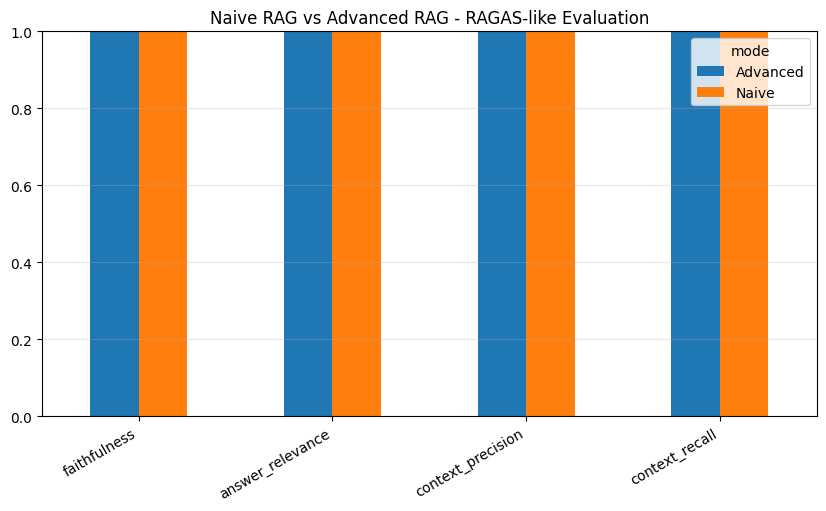

In [17]:
# ============================================================
# 16. 평가 결과 간단 시각화
# ============================================================

import matplotlib.pyplot as plt

score_cols = ["faithfulness", "answer_relevance", "context_precision", "context_recall"]
plot_df = eval_df.copy()

for c in score_cols:
    plot_df[c] = pd.to_numeric(plot_df[c], errors="coerce")

mean_df = plot_df.groupby("mode")[score_cols].mean()
print(mean_df)

ax = mean_df.T.plot(kind="bar", figsize=(10, 5))
plt.title("Naive RAG vs Advanced RAG - RAGAS-like Evaluation")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [18]:
# ============================================================
# 17. Gradio 앱 - 선택 실행
# ============================================================

# 이 셀은 선택입니다.
# 앞의 14번 테스트 셀이 정상 작동한 뒤 실행하세요.

RUN_GRADIO = True

if RUN_GRADIO:
    import gradio as gr
    import socket

    try:
        demo.close()
    except Exception:
        pass

    try:
        subprocess.run("pkill -f 'uvicorn|gradio|frpc' || true", shell=True, timeout=5)
        time.sleep(1)
    except Exception:
        pass

    def find_free_port(start=7860, end=7999):
        for port in range(start, end + 1):
            with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
                try:
                    s.bind(("0.0.0.0", port))
                    return port
                except OSError:
                    continue
        return None

    def safe_app_answer(question, mode):
        try:
            if not question or not question.strip():
                return "질문을 입력하세요.", "", ""

            question = question.strip()

            if mode == "Naive RAG":
                r = naive_rag(question, top_k=3)
                return r["answer"], format_docs(r["docs"]), "Naive RAG: 원본 질문 + 벡터 검색 + 기본 답변"

            if mode == "Advanced RAG":
                r = advanced_rag(question, top_k=6)
                debug = "질문 유형: " + r["label"] + "\n\n확장 질문:\n" + "\n".join("- " + q for q in r["queries"])
                return r["answer"], format_docs(r["docs"]), debug

            result = compare_rags(question)
            answer = "[Naive RAG]\n" + result["naive"]["answer"] + "\n\n" + "-" * 60 + "\n\n[Advanced RAG]\n" + result["advanced"]["answer"]
            docs = "[Naive 검색 문서]\n" + format_docs(result["naive"]["docs"]) + "\n\n" + "-" * 60 + "\n\n[Advanced 검색 문서]\n" + format_docs(result["advanced"]["docs"])
            debug = "[비교 평가]\n" + result["review"]
            return answer, docs, debug

        except Exception:
            return "오류가 발생했습니다.", "", traceback.format_exc()

    examples = [
        ["이동평균선 20일선을 돌파했는데 거래량이 별로 없으면 어떻게 봐야 하나요?", "Compare"],
        ["RSI 70 이상이고 볼린저밴드 상단에 닿으면 무조건 팔아야 하나요?", "Compare"],
        ["MACD 골든크로스가 나왔는데 주가는 60일선 아래에 있으면 어떻게 해석해야 하나요?", "Compare"],
        ["PER이 낮은데 영업이익이 줄고 있으면 저평가로 봐도 되나요?", "Compare"],
        ["AI 데이터센터 때문에 전력기기 섹터가 좋다고 하는데 어떤 지표를 확인해야 하나요?", "Advanced RAG"],
    ]

    with gr.Blocks(title="StockLens RAG Pro") as demo:
        gr.Markdown("""
        # StockLens RAG Pro
        주식 초보자를 위한 **재무제표·차트지표 기반 RAG 학습 튜터**입니다.
        이 시스템은 학습용 설명만 제공하며, 매수·매도 추천을 제공하지 않습니다.
        """)

        with gr.Row():
            question_box = gr.Textbox(label="질문", lines=3, placeholder="예: RSI 70 이상이면 무조건 팔아야 하나요?")
            mode_box = gr.Radio(["Naive RAG", "Advanced RAG", "Compare"], value="Compare", label="모드")

        btn = gr.Button("답변 생성", variant="primary")
        answer_box = gr.Textbox(label="답변", lines=20)
        docs_box = gr.Textbox(label="검색된 근거 문서", lines=8)
        debug_box = gr.Textbox(label="확장 질문 / 비교 평가 / 오류 로그", lines=12)

        gr.Examples(examples=examples, inputs=[question_box, mode_box])
        btn.click(safe_app_answer, inputs=[question_box, mode_box], outputs=[answer_box, docs_box, debug_box])

    port = find_free_port()
    if port is None:
        print("빈 포트를 찾지 못했습니다. 런타임을 재시작한 뒤 다시 실행하세요.")
    else:
        print("Gradio port:", port)
        try:
            demo.queue().launch(
                share=True,
                debug=False,
                server_name="0.0.0.0",
                server_port=port,
                prevent_thread_lock=True,
            )
        except Exception as e:
            print("Gradio share 실행 실패. RAG 기능은 정상입니다.")
            print(type(e).__name__, str(e))
            print("해결: 런타임 재시작 후 17번 셀만 다시 실행하거나, RUN_GRADIO=False로 두고 14번 테스트 셀을 사용하세요.")

Gradio port: 7860
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cb9c5070f15fa5fae4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 발표/제출용 핵심 설명

- **Naive RAG**: 원본 질문을 그대로 벡터 검색하여 기본 답변을 생성한다.
- **Advanced RAG**: 질문 유형을 분류하고 여러 검색 질문으로 확장한 뒤, 벡터 검색과 BM25를 결합한 Hybrid Search로 더 다양한 근거 문서를 가져온다.
- **차이점**: Advanced RAG는 단순 정의가 아니라 조건별 해석, 오해 교정, 함께 볼 지표, 체크리스트까지 제공한다.
- **평가**: RAGAS 패키지는 사용하지 않고, RAGAS의 4대 관점인 Faithfulness, Answer Relevance, Context Precision, Context Recall을 LLM-as-Judge로 평가한다.

In [20]:
import json

# 1. 업로드하신 원본 파일명을 적어줍니다.
# 코랩 환경에 '주식RAG2 (1).ipynb' 파일이 업로드되어 있어야 합니다.
notebook_path = "주식RAG2 (1).ipynb"

with open(notebook_path, "r", encoding="utf-8") as f:
    nb_data = json.load(f)

# 2. 깃허브 Invalid Notebook의 주범인 전체 metadata 내 widgets 폴더 제거
if "metadata" in nb_data and "widgets" in nb_data["metadata"]:
    del nb_data["metadata"]["widgets"]
    print("-> 노트북 전체 메타데이터에서 widgets 태그를 제거했습니다.")

# 3. 각 코드 셀 내부에서 출력을 깨지 않고 메타데이터 내 widgets만 제거
widget_cell_count = 0
for cell in nb_data.get("cells", []):
    if cell.get("cell_type") == "code":
        # 셀 내부 메타데이터 교정
        if "metadata" in cell and "widgets" in cell["metadata"]:
            del cell["metadata"]["widgets"]
            widget_cell_count += 1

        # 셀 출력결과(outputs) 내부의 jupyter widget 관련 찌꺼기 메타데이터 제거
        if "outputs" in cell:
            for output in cell["outputs"]:
                if "metadata" in output and "widgets" in output["metadata"]:
                    del output["metadata"]["widgets"]

print(f"-> 총 {widget_cell_count}개의 셀에서 오류 유발 위젯 코드를 안전하게 도려냈습니다.")
print("-> [주의] 기존 과제 결과물(텍스트, 그래프, 데이터프레임)은 그대로 유지되었습니다.")

# 4. 깃허브에 올릴 수 있도록 교정된 새로운 파일로 저장
clean_notebook_path = "Github_Ready_StockLens_RAG.ipynb"
with open(clean_notebook_path, "w", encoding="utf-8") as f:
    json.dump(nb_data, f, ensure_ascii=False, indent=2)

print(f"\n[성공] 최종본 파일 '{clean_notebook_path}'이 생성되었습니다.")
print("왼쪽 파일 메뉴에서 이 파일을 다운로드하여 깃허브에 업로드하세요!")

-> 노트북 전체 메타데이터에서 widgets 태그를 제거했습니다.
-> 총 0개의 셀에서 오류 유발 위젯 코드를 안전하게 도려냈습니다.
-> [주의] 기존 과제 결과물(텍스트, 그래프, 데이터프레임)은 그대로 유지되었습니다.

[성공] 최종본 파일 'Github_Ready_StockLens_RAG.ipynb'이 생성되었습니다.
왼쪽 파일 메뉴에서 이 파일을 다운로드하여 깃허브에 업로드하세요!
